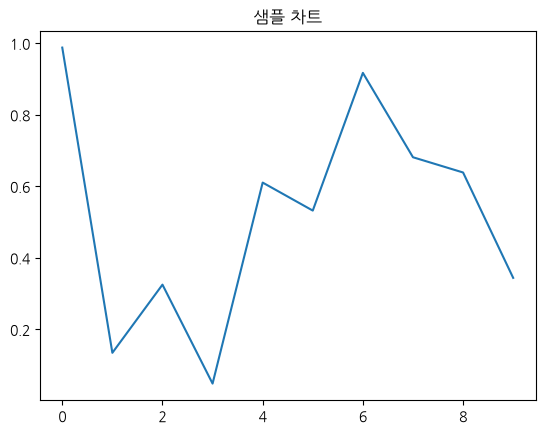

In [ ]:
import numpy as np

x = np.random.random(10)

import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.title('샘플 차트')
plt.plot(x)

In [2]:
import seaborn as sns
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import numpy as np

In [3]:
dm = sns.load_dataset('diamonds')

duckdb.sql("describe select * from dm").show()

┌─────────────┬──────────────────────────────────────────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│ column_name │                         column_type                          │  null   │   key   │ default │  extra  │
│   varchar   │                           varchar                            │ varchar │ varchar │ varchar │ varchar │
├─────────────┼──────────────────────────────────────────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ carat       │ DOUBLE                                                       │ YES     │ NULL    │ NULL    │ NULL    │
│ cut         │ ENUM('Ideal', 'Premium', 'Very Good', 'Good', 'Fair')        │ YES     │ NULL    │ NULL    │ NULL    │
│ color       │ ENUM('D', 'E', 'F', 'G', 'H', 'I', 'J')                      │ YES     │ NULL    │ NULL    │ NULL    │
│ clarity     │ ENUM('IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1') │ YES     │ NULL    │ NULL    │ NULL    │
│ depth       │ DOUBLE                          

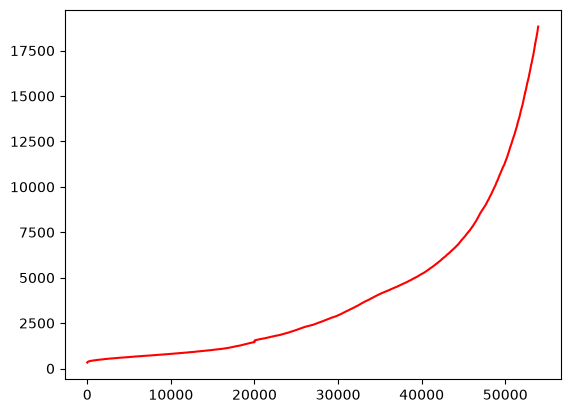

In [17]:
df = duckdb.sql("select carat, price from dm").df()
df_copy = df.sort_values('price').copy()
plt.plot(range(len(df_copy)), df_copy.price, 'r-')

In [24]:
dm.corr(numeric_only=True)

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


In [18]:
a = df.corr().iloc[1,0] * df['price'].std()/df['carat'].std()
b = df['price'].mean() - a * df['carat'].mean()
a, b

(np.float64(7756.425617968368), np.float64(-2256.36058004535))

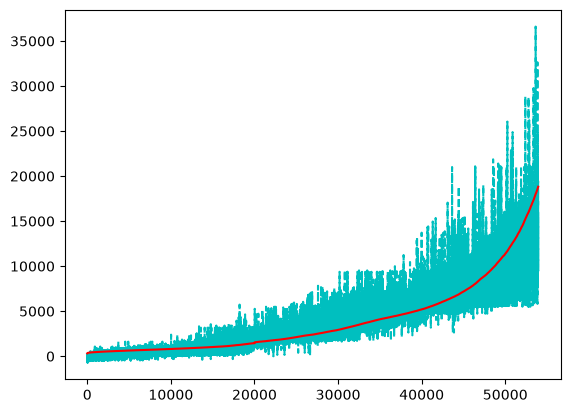

In [20]:
df['pred'] = a*df.carat + b

plt.plot(list(range(len(df))), df.sort_values('price').pred, 'c--')
plt.plot(list(range(len(df))),df.sort_values('price').price, 'r-')


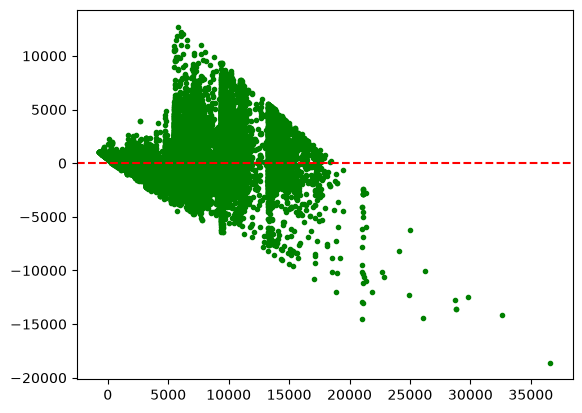

In [21]:
plt.plot(df.pred, df.price - df.pred, 'g.')
plt.axhline(0, color='red', linestyle='--')